Dataset Sample:

      Voltage   Current  Resistance  Temperature        Power  Frequency  \
0  237.450712  7.099033   33.448317    28.248217  1685.670479  46.184385   
1  227.926035  6.386951   35.686207    33.554813  1455.752312  48.279230   
2  239.715328  5.089446   47.100480    27.075801  1220.018111  49.172789   
3  252.845448  4.029595   62.747114    31.920385  1018.864710  53.775375   
4  226.487699  6.047335   37.452481    16.063853  1369.646985  51.113106   

   Fault  
0      1  
1      0  
2      0  
3      0  
4      0  

MODEL COMPARISON RESULTS

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression     0.790   0.651163  0.509091  0.571429
1        Decision Tree     0.965   0.928571  0.945455  0.936937
2        Random Forest     0.970   0.929825  0.963636  0.946429


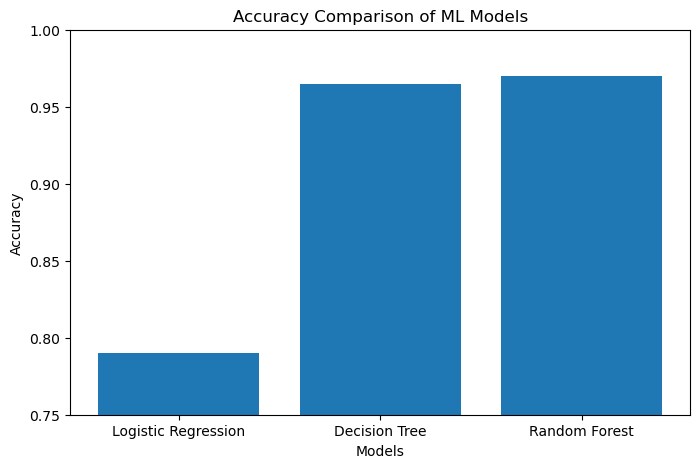

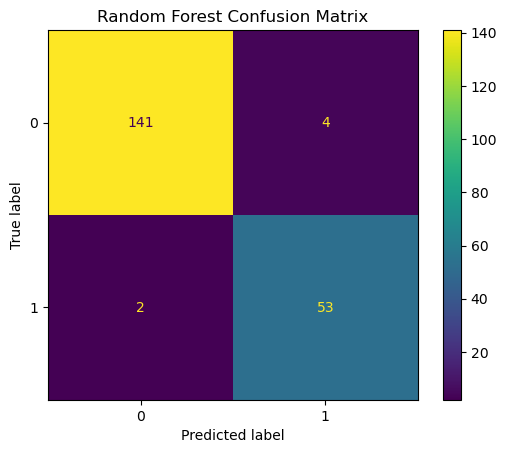

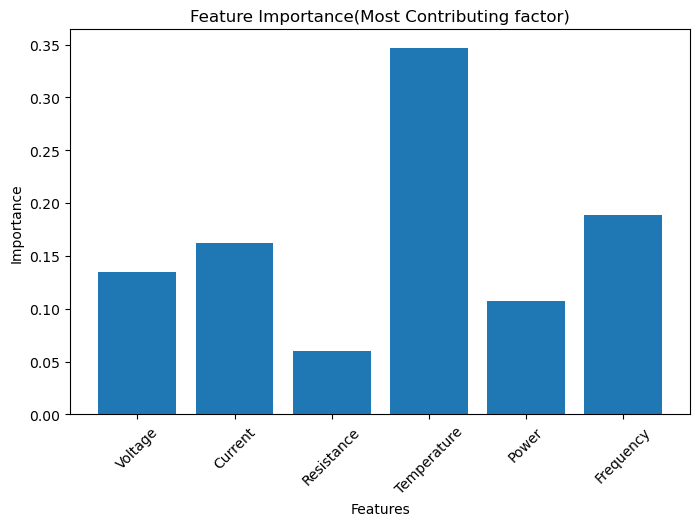

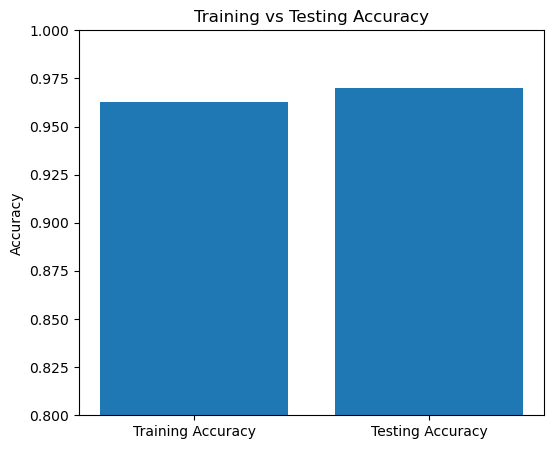

In [1]:

# ELECTRONIC CIRCUIT FAULT DETECTION PROJECT
# USING MACHINE LEARNING

# IMPORT LIBRARIES

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


# LOAD DATASET


data = pd.read_excel("ECE_Fault_Dataset.xlsx")

print("Dataset Sample:\n")

print(data.head())


# INPUT AND OUTPUT


X = data.drop('Fault', axis=1)

y = data['Fault']


# TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# MODEL 1 - LOGISTIC REGRESSION


lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)


# MODEL 2 - DECISION TREE


dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)


# MODEL 3 - RANDOM FOREST (ENSEMBLE MODEL)


rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


# EVALUATION FUNCTION


def evaluate_model(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred)

    recall = recall_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    return [accuracy, precision, recall, f1]


# GET RESULTS


lr_results = evaluate_model(y_test, lr_pred)

dt_results = evaluate_model(y_test, dt_pred)

rf_results = evaluate_model(y_test, rf_pred)


# RESULTS TABLE


results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        lr_results[0],
        dt_results[0],
        rf_results[0]
    ],

    'Precision': [
        lr_results[1],
        dt_results[1],
        rf_results[1]
    ],

    'Recall': [
        lr_results[2],
        dt_results[2],
        rf_results[2]
    ],

    'F1-Score': [
        lr_results[3],
        dt_results[3],
        rf_results[3]
    ]
})

print("\n====================================")

print("MODEL COMPARISON RESULTS")

print("====================================\n")

print(results)

# ============================================
# ACCURACY BAR GRAPH
# ============================================

plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['Accuracy']
)

plt.title("Accuracy Comparison of ML Models")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.ylim(0.75, 1.0)

plt.show()

# ============================================
# CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

# ============================================
# FEATURE IMPORTANCE GRAPH
# ============================================

importance = rf_model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.bar(features, importance)

plt.title("Feature Importance(Most Contributing factor)")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

# ============================================
# TRAINING VS TESTING ACCURACY
# ============================================

train_accuracy = rf_model.score(X_train, y_train)

test_accuracy = rf_model.score(X_test, y_test)

plt.figure(figsize=(6,5))

plt.bar(
    ['Training Accuracy', 'Testing Accuracy'],
    [train_accuracy, test_accuracy]
)

plt.title("Training vs Testing Accuracy")

plt.ylabel("Accuracy")

plt.ylim(0.8, 1.0)

plt.show()